In [1]:
# Import ScopeSim
import scopesim as sim
sim.link_irdb("../..")

import numpy as np

from scopesim import Simulation
from scopesim.source.source_templates import star_field

import matplotlib.pyplot as plt
import time

In [2]:
# Define source as a simple star field with some common spectrum
source = star_field(
    n=1000, 
    mmax=10,    # [mag]
    mmin=20, 
    width=3600,  # [arcsec]
)

source.fields

[TableSourceField(field=<Table length=1000>
          x                   y          ...  ref         mag       
        arcsec              arcsec       ...              mag       
       float64             float64       ... int64      float64     
 ------------------- ------------------- ... ----- -----------------
 0.40879806132649854  1174.8490844543128 ...     0              20.0
  1363.9016165832252  453.91690420204174 ...     0 19.98998998998999
  -932.0678614938289    254.160079549702 ...     0 19.97997997997998
  -845.8563324727344  -618.8168466715537 ...     0 19.96996996996997
   917.4000956007922  -74.80058796798632 ...     0 19.95995995995996
   472.2714399159561  1719.4651551709533 ...     0 19.94994994994995
 -1526.3620667569842   302.0004694997571 ...     0 19.93993993993994
 -1635.1324485205932  1103.3654373394256 ...     0 19.92992992992993
 -1377.3937322459292   926.5525165308914 ...     0 19.91991991991992
                 ...                 ... ...   ...         

In [3]:
# Generate and run a simulation
t0 = time.time()
simulation = Simulation("UVEX", mode=['fuv']) # Use mode=['nuv'] for an NUV image
hdulist = simulation(source)
print(f"simulation completed in {time.time() - t0: .2f} s")

astar.scopesim.utils - ERROR: File cannot be found: tbd_ipc_kernel.fits


 FOVs:   0%|          | 0/49 [00:00<?, ?it/s]

FitsIllumination image-plane shape: (13088, 12788)
FitsIllumination input-map shape: (4096, 4096)
Interpolating illumination map:
FitsIllumination interpolated shape: (13088, 12788)
astar.scopesim.detector.detector_manager - Extracting from 9 detectors...
astar.scopesim.effects.electronic - WARNING: Effect ShotNoise: 8386029 negative pixels
astar.scopesim.effects.electronic.electrons - Applying gain 1.2
astar.scopesim.effects.electronic - WARNING: Effect ShotNoise: 8386029 negative pixels
astar.scopesim.effects.electronic.electrons - Applying gain 1.2
astar.scopesim.effects.electronic - WARNING: Effect ShotNoise: 8386029 negative pixels
astar.scopesim.effects.electronic.electrons - Applying gain 1.2
astar.scopesim.effects.electronic - WARNING: Effect ShotNoise: 8386029 negative pixels
astar.scopesim.effects.electronic.electrons - Applying gain 1.2
astar.scopesim.effects.electronic - WARNING: Effect ShotNoise: 8380325 negative pixels
astar.scopesim.effects.electronic.electrons - Applyin

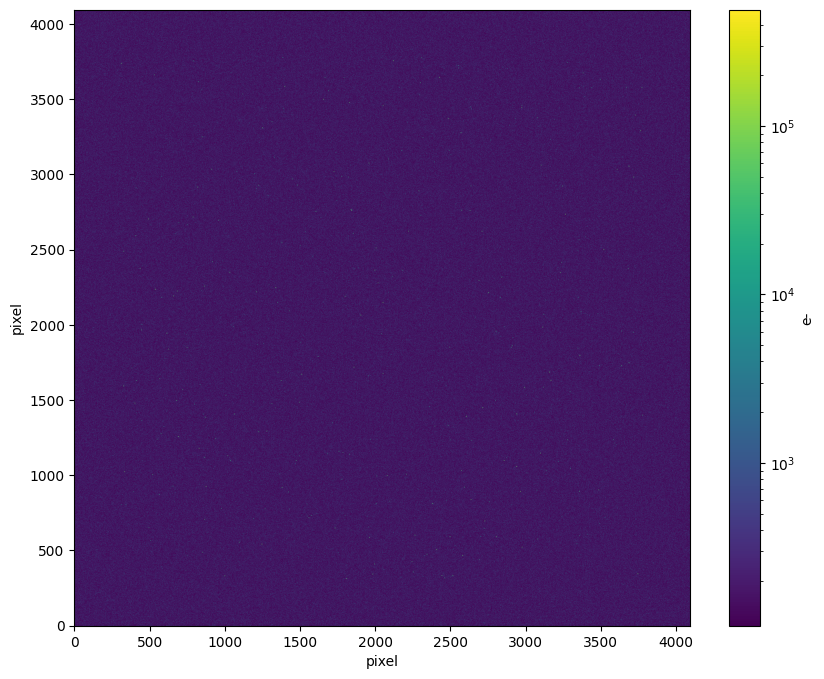

In [6]:
# Plot the central detector (hdu 5 of 9)

plt.figure(figsize=(10, 8))
plot_data = hdulist[5].data.copy()
plot_data = np.float64(plot_data) * hdulist[5].header['GAIN'] #Convert to -e units
#plot_data[plot_data <= 0] = 1e-2
plt.imshow(plot_data, origin="lower", norm="log")
#plt.xlim(1500, 2500)
#plt.ylim(1500, 2500)
plt.ylabel('pixel')
plt.xlabel('pixel')
plt.colorbar(label='e-')
plt.show()

In [7]:
# Some numbers (units of counts)

img5 = hdulist[5].data
print("shape_img5:", img5.shape)
print("min_img5, max_img5:", img5.min(), img5.max())
print("sum_img5:", img5.sum())
print("mean_img5", np.mean(img5))
print("median_img5", np.median(img5))

shape_img5: (4096, 4096)
min_img5, max_img5: 90.0 408090.0
sum_img5: 5635693440.0
mean_img5 335.9135055541992
median_img5 90.0
